# Stellar Coordinate Explorer - Basic Visualization (RA vs Dec)

## Objective
Create your first astronomical plot: a simple scatter plot of Right Ascension vs Declination for the 10,000 stars in the catalog.

## Why this matters for radio astronomy
- Before any observation run, radio astronomers often plot source positions to check sky coverage and identify potential calibrators.
- A simple RA-Dec plot reveals large-scale patterns (e.g., the Milky Way plane, avoidance of the Galactic plane in some surveys).
- This is also the foundation for more advanced projections like Aitoff or Mollweide.

## Dataset
- Input: `stars_with_galactic.fits`
- Columns used: `ra`, `dec`, `phot_g_mean_mag`

## Goals for Today
- Load the enhanced 10,000-star table (with Galactic coordinates, but we use RA/Dec)
- Generate a standard `matplotlib` scatter plot of Dec vs RA
- Label axes correctly (RA in degress, Dec in degrees)
- Observe and note any patterns (e.g., gaps, clusters, the Galactic plane)

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table

# Load the table
table = Table.read("../../data/stars_with_galactic.fits")

Let's check for missing data in the `ra` and `dec` columns

In [7]:
table.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    14


The columns `ra` and `dec` appear to have no missing values (`n_bad` is 0 for both columns). We can now prepare them for plotting.

In [9]:
ra = table['ra']
dec = table['dec']

Now we create our scatter plot.

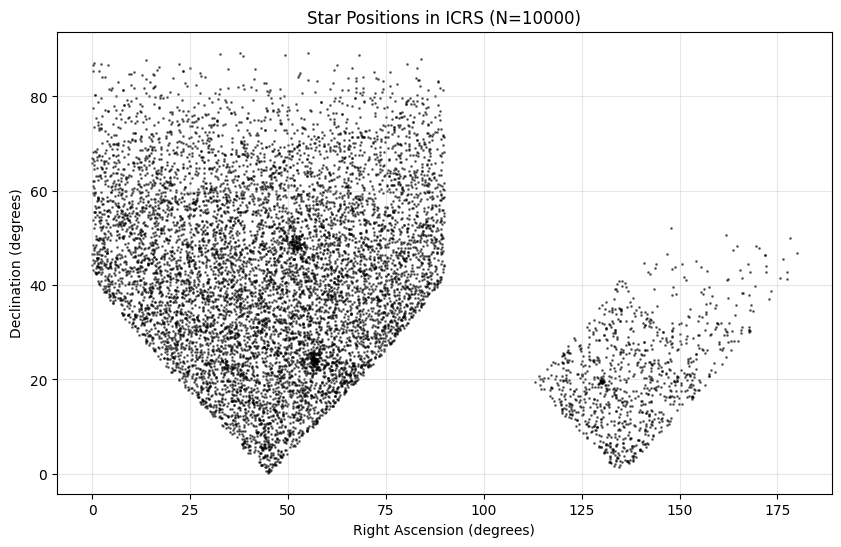

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(ra, dec, s=1, alpha=0.5, color='black')
plt.xlabel("Right Ascension (degrees)")
plt.ylabel("Declination (degrees)")
plt.title(f"Star Positions in ICRS (N={len(table)})") 
plt.grid(True, alpha=0.3)
plt.show()

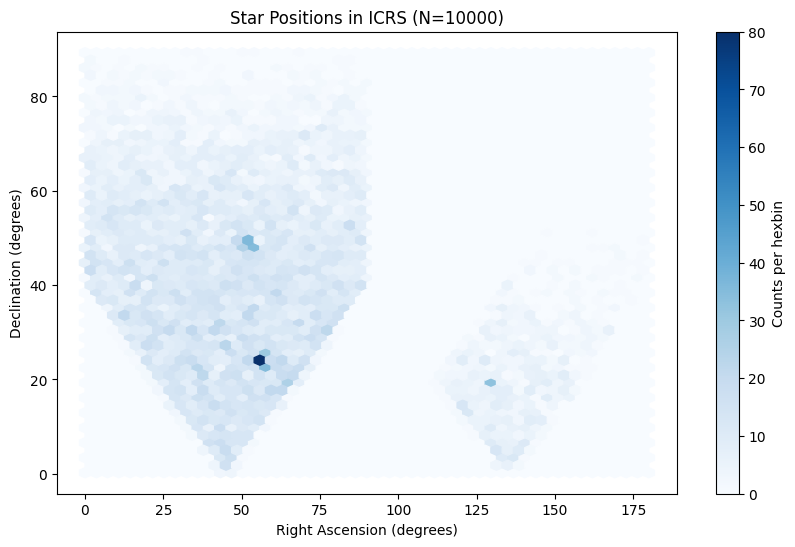

In [12]:
plt.figure(figsize=(10, 6))
plt.hexbin(ra, dec, gridsize=50, cmap='Blues') 
plt.colorbar(label='Counts per hexbin')
plt.xlabel("Right Ascension (degrees)")
plt.ylabel("Declination (degrees)")
plt.title(f"Star Positions in ICRS (N={len(table)})") 
plt.show()

## Observation
The star distribution appears in distinct geometric regions rather than a continuous sky coverage.


## Intepretation

This pattern is not astrophysical but results from the data selection process. The Gaia subset used here does not uniformly sample the sky, leading to visible boundaries in RA/Dec space.

## Implication
To study true spatial structure, a more uniformly sampled dataset is required.